# Analyse Exploratoire - Projet Seattle
### Prédiction des émissions de la consommation d'énergie des bâtiments

**Objectif** : Aider la ville de Seattle à atteindre son objectif de neutralité carbone en 2050 en prédisant les émissions de CO2 ou la consommation d'énergie des bâtiments non résidentiels à partir de leurs caractéristiques structurelles.

Données : Relevés de consommation énergétique des bâtiments de Seattle en 2016

Étapes de cette analyse :

    1/Configuration et chargement des données
    2/ Vue d'ensemble du dataset
    3/ Nettoyage des données
    4/ Choix de la variable cible
    5/ Analyse de la variable cible
    6/ Analyse des outliers de la variable cible
    7/ Visualisation des Features incomplètes
    Conclusions et prochaines étapes

## 1/Configuration et imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from category_encoders import BinaryEncoder

In [2]:
!python --version
print('\n'.join(f'{m.__name__} - {m.__version__}' 
                for m in globals().values() 
                if getattr(m, '__version__', None)))

Python 3.13.11
pandas - 2.3.3
numpy - 1.26.4


In [3]:
df_initial = pd.read_csv('https://s3.eu-west-1.amazonaws.com/course.oc-static.com/projects/Data_Scientist_P4/2016_Building_Energy_Benchmarking.csv')
df=df_initial
print("Dataset chargé avec succès")
print(f"Dimensions : {df.shape[0]} lignes × {df.shape[1]} colonnes")

Dataset chargé avec succès
Dimensions : 3376 lignes × 46 colonnes


---
## 2/ Vue d'ensemble du dataset

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3376 entries, 0 to 3375
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    3376 non-null   int64  
 1   DataYear                         3376 non-null   int64  
 2   BuildingType                     3376 non-null   object 
 3   PrimaryPropertyType              3376 non-null   object 
 4   PropertyName                     3376 non-null   object 
 5   Address                          3376 non-null   object 
 6   City                             3376 non-null   object 
 7   State                            3376 non-null   object 
 8   ZipCode                          3360 non-null   float64
 9   TaxParcelIdentificationNumber    3376 non-null   object 
 10  CouncilDistrictCode              3376 non-null   int64  
 11  Neighborhood                     3376 non-null   object 
 12  Latitude            

In [5]:
#afficher les 1eres lignes
display(df.head())

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,...,Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,...,1.156514e+06,3946027.0,12764.52930,1276453.0,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,...,9.504252e+05,3242851.0,51450.81641,5145082.0,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,...,1.451544e+07,49526664.0,14938.00000,1493800.0,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,...,8.115253e+05,2768924.0,18112.13086,1811213.0,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,...,1.573449e+06,5368607.0,88039.98438,8803998.0,False,NaN,Compliant,NaN,505.01,2.88


---
### 2.1 Analyse des types de données

In [6]:
type_counts = df.dtypes.value_counts()

print("="*80)
print("📊 RÉPARTITION DES TYPES DE DONNÉES")
print("="*80)
for dtype, count in type_counts.items():
    print(f"  {dtype}: {count} colonnes")
print("="*80)

# Séparer par catégorie
numeriques = df.select_dtypes(include=[np.number]).columns.tolist()
categorielles = df.select_dtypes(include=['object']).columns.tolist()
booleens = df.select_dtypes(include=['bool']).columns.tolist()

print(f"\n✅ Variables numériques : {len(numeriques)}")
print(f"✅ Variables catégorielles : {len(categorielles)}")
print(f"✅ Variables booléennes : {len(booleens)}")

📊 RÉPARTITION DES TYPES DE DONNÉES
  float64: 22 colonnes
  object: 15 colonnes
  int64: 8 colonnes
  bool: 1 colonnes

✅ Variables numériques : 30
✅ Variables catégorielles : 15
✅ Variables booléennes : 1


---
### 2.2 Première analyse du dataset

On peut voir que notre dataset comporte en majorité des **variables numériques**, puis des variables catégorielles, et 1 valeur booléenne.  
  
Il est possible de définir  :

1. **des catégories de variables**, en voici une partie :   
 - `variable de localisation` :Address,City,State,ZipCode,CouncilDistrictCode,Neighborhood,Latitude,Longitude.  
 - `variable d'utilisation` :ListOfAllPropertyUseTypes,LargestPropertyUseType,SecondLargestPropertyUseType, 
 - `variable énergétique` :YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh), Electricity(kBtu),NaturalGas(therms),PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseTypeGFA,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,TotalGHGEmissions,GHGEmissionsIntensity, YearsENERGYSTARCertified,ENERGYSTARScore .
 - `variable structurelle` :NumberofBuildings,NumberofFloors,PrimaryPropertyType, BuildingType.    

2. **D'autres variables vont nous permettre d'identifier des individus non conforme** et ainsi de les supprimer du Dataset.  
 - Outlier : qui sont des individus hors normes
 - CompliantStatus :  les individus qui ne sont pas compliant
 - DefaultData:  supprimée les données estimées par défaut


3. **Des variables non pertientes qui** :
 - ne varient pas : DataYear : 2016, et City : Seattle
 - apportent de mêmes informations concernant la localisation (**address, city, state, Zipcode**).Les  plus pertinentes sur le sujet : **CouncilDistrictCode** et **Neighborhood**.
 - sont constitués arbitrairement : Property Name (nom des batiments), TaxParcelIdentificationNumber
 - font doublons car déjà calculé en kBtu : Electricity(kWh), NaturalGas(therms)
 - sont complétement vide : Comments
    

---
 ## 3/ Nettoyage des données

Avant toute modélisation, il est essentiel de nettoyer les données pour garantir la qualité et la fiabilité de nos prédictions.  
Cette étape de nettoyage vise à éliminer les données aberrantes, redondantes ou non conformes qui pourraient biaiser la modélisation.

### 3.1 Les types de propriété
Le Dataset possède plusieurs variables pour définir le type de batiments
Regardons si elles sont toutes utiles

In [7]:
colonnes_a_afficher = ['BuildingType','PrimaryPropertyType', 'ListOfAllPropertyUseTypes','LargestPropertyUseType']
display(df[colonnes_a_afficher].head(10))

,BuildingType,PrimaryPropertyType,ListOfAllPropertyUseTypes,LargestPropertyUseType
0,NonResidential,Hotel,Hotel,Hotel
1,NonResidential,Hotel,"Hotel, Parking, Restaurant",Hotel
2,NonResidential,Hotel,Hotel,Hotel
3,NonResidential,Hotel,Hotel,Hotel
4,NonResidential,Hotel,"Hotel, Parking, Swimming Pool",Hotel
5,Nonresidential COS,Other,Police Station,Police Station
6,NonResidential,Hotel,Hotel,Hotel
7,NonResidential,Other,Other - Entertainment/Public Assembly,Other - Entertainment/Public Assembly
8,NonResidential,Hotel,Hotel,Hotel
9,Multifamily MR (5-9),Mid-Rise Multifamily,Multifamily Housing,Multifamily Housing


---

Nous voyons que ListOfAllPropertyUseTypes et LargestPropertyUseType sont identiques.  
Je supprime ListOfAllPropertyUseTypes.

---

### 3.1.Suppression des doublons, outliers et données non-conformes

Dans l'analyse du dataset, nous avons eu une première vision de données non conforme :
 - Variables redondantes et non pertinentes
 - les Outliers
 - le Compliance Statut

#### a. Variables redondantes et non pertinentes

##### a.1 DefaultData

In [8]:
print("\nDistribution des valeurs 'DefaultData' :")

print("\n 🎯  Valeurs uniques (DefaultData) :")
print(df['DefaultData'].unique())


Distribution des valeurs 'DefaultData' :

 🎯  Valeurs uniques (DefaultData) :
[False  True]


---

Il n'y a pas de données par défaut, nous pouvons supprimer cette variable.

---

In [9]:
colonnes_a_supprimer =[
    'OSEBuildingID',
    'PropertyName',
    'Address',
    'City',
    'State',
    'ZipCode',
    'TaxParcelIdentificationNumber',
    'Electricity(kWh)',
    'NaturalGas(therms)',
    'Comments', 
    'ListOfAllPropertyUseTypes',
    'DefaultData'
]

df = df.drop(columns=colonnes_a_supprimer)

print(f"Après suppression des colonnes non pertinentes. Le nouveau dataset est composé de {df.shape[0]} lignes et de {df.shape[1]} colonnes" )

Après suppression des colonnes non pertinentes. Le nouveau dataset est composé de 3376 lignes et de 34 colonnes


#### b. Colonne Outlier du Dataset

In [10]:
index_outlier = df[df['Outlier'].notna()].index
df.drop(index = index_outlier, inplace=True)

df.drop(columns=['Outlier'], inplace=True)
print(f"Après la suppression des Outlier. Le nouveau dataset est composé de {df.shape[0]} lignes et de {df.shape[1]} colonnes" )

Après la suppression des Outlier. Le nouveau dataset est composé de 3344 lignes et de 33 colonnes


#### c. Individus 'non compliant' de la variable Compliance statuts

In [11]:
print("\nDistribution des valeurs 'ComplianceStatus' :")
print(df['ComplianceStatus'].value_counts(normalize=True))

# GARDER seulement 'Compliant' 
df = df[df['ComplianceStatus']== 'Compliant']

print("\n 🎯  Valeurs uniques (ComplianceStatus) :")
print(df['ComplianceStatus'].unique())


Distribution des valeurs 'ComplianceStatus' :
ComplianceStatus
Compliant                       0.960227
Error - Correct Default Data    0.033194
Missing Data                    0.004486
Non-Compliant                   0.002093
Name: proportion, dtype: float64

 🎯  Valeurs uniques (ComplianceStatus) :
['Compliant']


---
### 3.2. Suppression des individus possédant + de 4 batiments

Le dataset nous fournit la `consommation énergétique totale par individus` peu importe le nombre de bâtiments qu'il contient. Pour les individus possédant plus de 4 bâtiments, cette consommation cumulée ne permet pas d'`identifier les caractéristiques énergétiques de chaque bâtiment individuellement`.  
La situation idéale serait de se conformer à un individu pour un bâtiment, mais pour ne pas tronquer de façon trop importante le Dataset, je conserve les individus qui ont entre 1 et 4 bâtiments.  

In [12]:
print("\n" + "="*90)
print("Distribution des individus en fonction de leur nombre de bâtiments")
print("="*90)

# Filtrer le(s) bâtiment(s) par étage
batiment_etages = df[df['NumberofBuildings'] > 3]

print(batiment_etages.shape[0])
# Afficher les informations clés
colonnes_a_afficher = ['PrimaryPropertyType', 'PropertyGFABuilding(s)', 
                       'SiteEnergyUse(kBtu)', 'NumberofBuildings',]

display(batiment_etages[colonnes_a_afficher])


Distribution des individus en fonction de leur nombre de bâtiments
41


,PrimaryPropertyType,PropertyGFABuilding(s),SiteEnergyUse(kBtu),NumberofBuildings
98,Hospital,285333,6.809073e+07,4.0
105,University,441071,3.830174e+07,27.0
124,Hospital,879000,2.538325e+08,6.0
128,University,582447,3.589148e+07,11.0
162,Large Office,302494,5.346668e+07,14.0
167,Hospital,597519,1.434230e+08,6.0
170,Hospital,1158691,2.930908e+08,9.0
195,Other,215476,2.401777e+07,4.0
364,Other,111900,9.814820e+06,6.0
618,Hospital,1765970,2.916144e+08,7.0


In [13]:
df.drop(index=batiment_etages.index, inplace=True)
print(f"Après la suppression des individus de + de 4 batiments. Le nouveau dataset est composé de {df.shape[0]} lignes et de {df.shape[1]} colonnes" )

Après la suppression des individus de + de 4 batiments. Le nouveau dataset est composé de 3170 lignes et de 33 colonnes


---
### 3.3.Suppression des individus ayant une utilisation `résidentiel`

Plusieurs individus possède en **première utilisation** une catégorie **habitation residentiel**.  
Notre étude se porte sur les **individus non résidentiel**.  
**Conclusion :** je vais supprimer les individus ayant une principale utilisation résidentielle.

In [14]:
print("\n" + "="*90)
print("VUE SYNTHÉTIQUE des 20 premiers individus selon le type de bâtiment et leur utilisation")
print("="*90)
synthese = df.groupby(['BuildingType', 'PrimaryPropertyType','LargestPropertyUseType','SecondLargestPropertyUseType', 'ThirdLargestPropertyUseType']).size().reset_index(name='Count')
synthese_sorted = synthese.sort_values('Count', ascending=False)
display(synthese_sorted.head(20))


VUE SYNTHÉTIQUE des 20 premiers individus selon le type de bâtiment et leur utilisation


,BuildingType,PrimaryPropertyType,LargestPropertyUseType,SecondLargestPropertyUseType,ThirdLargestPropertyUseType,Count
89,Multifamily MR (5-9),Mid-Rise Multifamily,Multifamily Housing,Parking,Retail Store,29
82,Multifamily MR (5-9),Mid-Rise Multifamily,Multifamily Housing,Parking,Office,22
143,NonResidential,Large Office,Office,Parking,Other,17
41,Multifamily LR (1-4),Low-Rise Multifamily,Multifamily Housing,Parking,Office,15
19,Multifamily HR (10+),High-Rise Multifamily,Multifamily Housing,Parking,Retail Store,8
46,Multifamily LR (1-4),Low-Rise Multifamily,Multifamily Housing,Parking,Retail Store,8
149,NonResidential,Large Office,Office,Parking,Restaurant,7
30,Multifamily LR (1-4),Low-Rise Multifamily,Multifamily Housing,Office,Parking,6
49,Multifamily LR (1-4),Low-Rise Multifamily,Multifamily Housing,Parking,Swimming Pool,6
88,Multifamily MR (5-9),Mid-Rise Multifamily,Multifamily Housing,Parking,Restaurant,6


In [15]:
types_non_residentiels = [
    'NonResidential',
    'SPS-District K-12',
    'Nonresidential COS',
    'Campus',
    'Nonresidential WA'
]

df = df[df['BuildingType'].isin(types_non_residentiels)].copy()

print(f"\nAPRÈS SUPPRESSION DES BATIMENTS RESIDENTIELS :")
print(f"Nombre de lignes conservées : {len(df)}")
print(f"Nombre de lignes supprimées : {len(df) - len(df)}")

print(f"\n Types de bâtiments restants :")
print(df['BuildingType'].value_counts())
print("\n" + "="*90)
print(f"Le nouveau dataset est composé de {df.shape[0]} lignes et de {df.shape[1]} colonnes" )
print("="*90)


APRÈS SUPPRESSION DES BATIMENTS RESIDENTIELS :
Nombre de lignes conservées : 1522
Nombre de lignes supprimées : 0

 Types de bâtiments restants :
BuildingType
NonResidential        1420
Nonresidential COS      79
Campus                  12
SPS-District K-12       10
Nonresidential WA        1
Name: count, dtype: int64

Le nouveau dataset est composé de 1522 lignes et de 33 colonnes


---

## 4 / Choix de la variable cible

Pour prédire la performance énergétique des bâtiments, deux variables sont pertinentes :
- **TotalGHGEmissions** : mesure directement l'impact carbone
- **SiteEnergyUse(kBtu)** : quantifie la consommation énergétique totale  

Nous allons comparer la qualité des données de ces deux variables pour faire un choix éclairé.

#### 4.1.Évaluation de la qualité des variables cibles possibles via la methode 'describe'

In [16]:
print("\n1️⃣ TotalGHGEmissions (émissions de CO2)")
print("-"*80)
print(df['TotalGHGEmissions'].describe())
print(f"\nValeurs manquantes : {df['TotalGHGEmissions'].isnull().sum()} ({df['TotalGHGEmissions'].isnull().sum()/len(df)*100:.1f}%)")

print("\n2️⃣ SiteEnergyUse(kBtu) (consommation d'énergie)")
print("-"*80)
print(df['SiteEnergyUse(kBtu)'].describe().round(1))
print(f"\nValeurs manquantes : {df['SiteEnergyUse(kBtu)'].isnull().sum()} ({df['SiteEnergyUse(kBtu)'].isnull().sum()/len(df)*100:.1f}%)")


1️⃣ TotalGHGEmissions (émissions de CO2)
--------------------------------------------------------------------------------
count     1522.000000
mean       156.267043
std        542.021796
min         -0.800000
25%         20.135000
50%         49.285000
75%        139.502500
max      16870.980000
Name: TotalGHGEmissions, dtype: float64

Valeurs manquantes : 0 (0.0%)

2️⃣ SiteEnergyUse(kBtu) (consommation d'énergie)
--------------------------------------------------------------------------------
count         1522.0
mean       7436655.0
std       18178780.9
min          57133.2
25%        1242702.6
50%        2654851.8
75%        6991989.4
max      448385312.0
Name: SiteEnergyUse(kBtu), dtype: float64

Valeurs manquantes : 0 (0.0%)


In [17]:
print("="*80)
print("ANALYSE DES VARIABLES CIBLES")
print("="*80)


print("\nVariable TotalGHGEmissions :")
print(f" -Le min est {df['TotalGHGEmissions'].min():.2f}, Nous avons une valeur négative")
print("     → certains bâtiments produisent de l'énergie (par exemple s'il possède des panneau solaires).")
print("       cette information peut être pertinente, mais n'est pour l'instant pas exploitable. Il peut-être pertinent de le prendre en compte dans la future prise de données")

print(f" - La médiane d'émissions est de {df['TotalGHGEmissions'].median():.2f} (2ᵉ quartile)")
print(f" - La valeur max est de {df['TotalGHGEmissions'].max():.2f}")
print(f" - La valeur max est de {df['TotalGHGEmissions'].mean():.2f}")
print("    → Un important écart est constaté entre la médiane et la moyenn")
print("    → Un important écart est constaté entre le dernier quartyle et la valeur maximum")
print("    → Ce résultat nous indique qu'il y a sûrement des outliers")


print("\nVariable SiteEnergyUse(kBtu) :")
print(f" - 75% des bâtiments consomment moins de {df['SiteEnergyUse(kBtu)'].quantile(0.75):.2e} kBtu")
print(f"   et la moyenne de consommation est de {df['SiteEnergyUse(kBtu)'].mean():.2e} Kbtu") 
print("      → Cela signifie que plus de 75% des bâtiments sont en dessous de la moyenne")
print(f" - La moyenne ({df['SiteEnergyUse(kBtu)'].mean():.2e}) est {df['SiteEnergyUse(kBtu)'].mean()/df['SiteEnergyUse(kBtu)'].median():.1f} x supérieure à la médiane ({df['SiteEnergyUse(kBtu)'].median():.2e})")
print(f" - Valeur max : {df['SiteEnergyUse(kBtu)'].max():.2e} kBtu (bien supérieur à la médiane et à la moyenne)")
print("      → ce sont sûrement les outliers qui faussent la moyenne et creuse l'écart avec la valeur maximal de consommation.")

print("\n" + "="*80)
print("CHOIX RETENU : SiteEnergyUse(kBtu)")
print("="*80)
print("Justification : Cette variable présente moins de valeurs les plus exploitables pour la modélisation")

ANALYSE DES VARIABLES CIBLES

Variable TotalGHGEmissions :
 -Le min est -0.80, Nous avons une valeur négative
     → certains bâtiments produisent de l'énergie (par exemple s'il possède des panneau solaires).
       cette information peut être pertinente, mais n'est pour l'instant pas exploitable. Il peut-être pertinent de le prendre en compte dans la future prise de données
 - La médiane d'émissions est de 49.28 (2ᵉ quartile)
 - La valeur max est de 16870.98
 - La valeur max est de 156.27
    → Un important écart est constaté entre la médiane et la moyenn
    → Un important écart est constaté entre le dernier quartyle et la valeur maximum
    → Ce résultat nous indique qu'il y a sûrement des outliers

Variable SiteEnergyUse(kBtu) :
 - 75% des bâtiments consomment moins de 6.99e+06 kBtu
   et la moyenne de consommation est de 7.44e+06 Kbtu
      → Cela signifie que plus de 75% des bâtiments sont en dessous de la moyenne
 - La moyenne (7.44e+06) est 2.8 x supérieure à la médiane (2.65e+

---

## 5/ Partie 1 : Analyse de la variable cible : SiteEnergyUse(kBtu)
 - Analyse avec l'**annés de construction** de batiments
 - Analyse avec la **surface** de batiments
 - Analyse avec le **type** de batiments
 

#### 5.1 Suppression des bâtiments sans consommation élétrique

In [18]:
print(f"\n📊 AVANT suppression :")
print(f"   Nombre total de bâtiments : {len(df)}")
nb_elec_zero = (df['Electricity(kBtu)'] == 0).sum()
print(f"   Bâtiments avec Electricity = 0 : {nb_elec_zero}")

# Suppression
df = df[df['Electricity(kBtu)'] != 0]

# État après
print(f"\n📊 APRÈS suppression :")
print(f"   Nombre total de bâtiments : {len(df)}")
nb_elec_zero_apres = (df['Electricity(kBtu)'] == 0).sum()
print(f"   Bâtiments avec Electricity = 0 : {nb_elec_zero_apres}")

print(f"\n✅ {nb_elec_zero} bâtiments supprimés")


📊 AVANT suppression :
   Nombre total de bâtiments : 1522
   Bâtiments avec Electricity = 0 : 2

📊 APRÈS suppression :
   Nombre total de bâtiments : 1520
   Bâtiments avec Electricity = 0 : 0

✅ 2 bâtiments supprimés


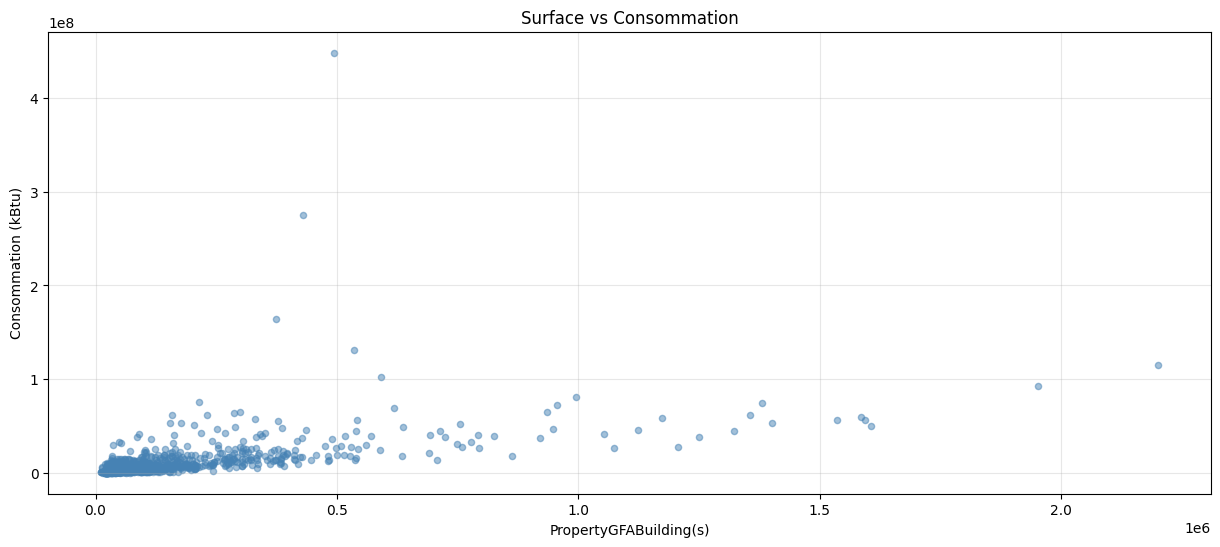

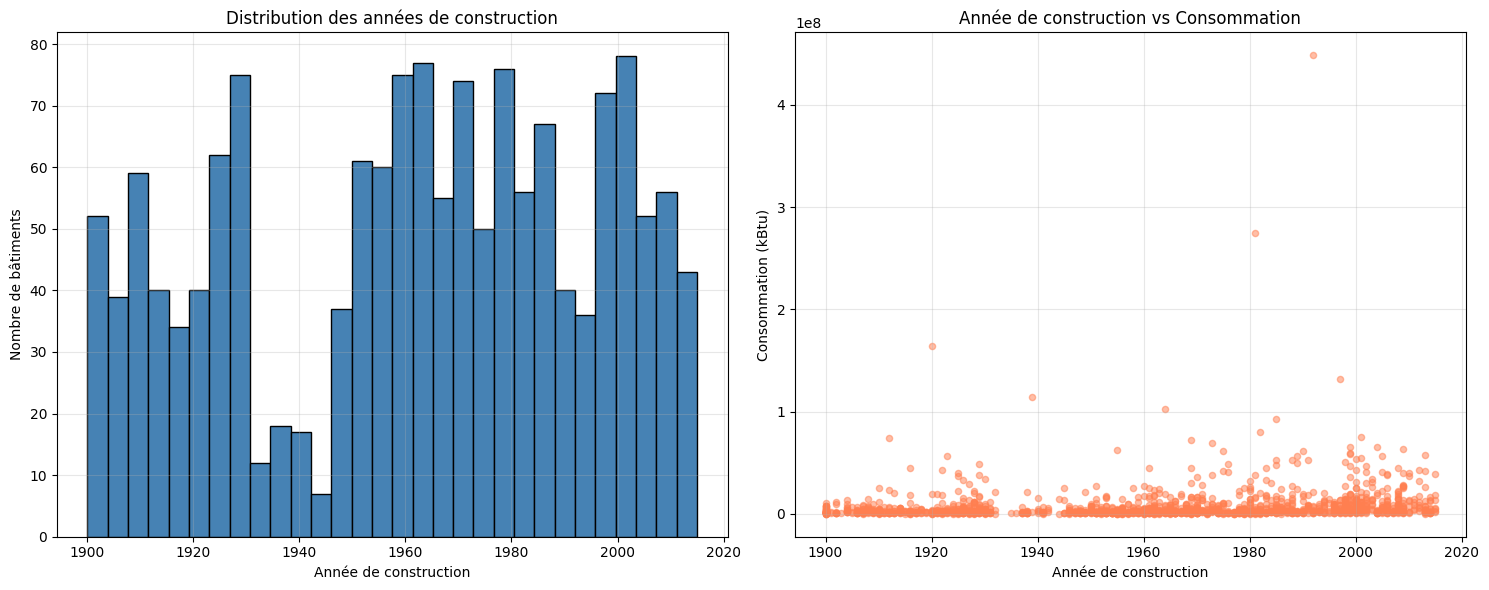

In [19]:
fig, axes = plt.subplots(1, 1, figsize=(15, 6))

# Graphique 1 : Scatter plot
axes.scatter(df['PropertyGFATotal'], 
                df['SiteEnergyUse(kBtu)'], 
                alpha=0.5, s=20, color='steelblue')
axes.set_xlabel('PropertyGFABuilding(s)')
axes.set_ylabel('Consommation (kBtu)')
axes.set_title('Surface vs Consommation')
axes.grid(True, alpha=0.3)

# ============================================================================
# 4. ANNÉE DE CONSTRUCTION vs Consommation
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Graphique 1 : Distribution des années
axes[0].hist(df['YearBuilt'], bins=30, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Année de construction')
axes[0].set_ylabel('Nombre de bâtiments')
axes[0].set_title('Distribution des années de construction')
axes[0].grid(True, alpha=0.3)

# Graphique 2 : Année vs Consommation
axes[1].scatter(df['YearBuilt'], 
                df['SiteEnergyUse(kBtu)'], 
                alpha=0.5, s=20, color='coral')
axes[1].set_xlabel('Année de construction')
axes[1].set_ylabel('Consommation (kBtu)')
axes[1].set_title('Année de construction vs Consommation')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Le nuage de points *Surface VS Consommation* nous montre que **quelques batiments avec une petite surface** présente une **consommation d'énergie très élevée**. 
Les individus avec **les plus grandes surfaces** n'augmentent pas leur consommation en proportion de leur taille.  
**conclusion**: La surface seule n'explique pas la consommation énergétique. D'autres facteurs (type d'usage, âge du bâtiment, isolation, équipements) jouent un rôle déterminant.

L'analyse croisée entre les années de construction, le nombre de batiments et la consommation d'energie montre qu'il n'y a pas de relation directe entre le nombre de batiments construits sur une année donnée. Les années avec beaucoup de constructions ne sont pas forcément celles qui génèrent le plus de consommation. On remarque entre 1990 et 2000, quelques individus energivores.

#### 5.2 Analyse des distributions d'énergie VS Surfaces(GFA)

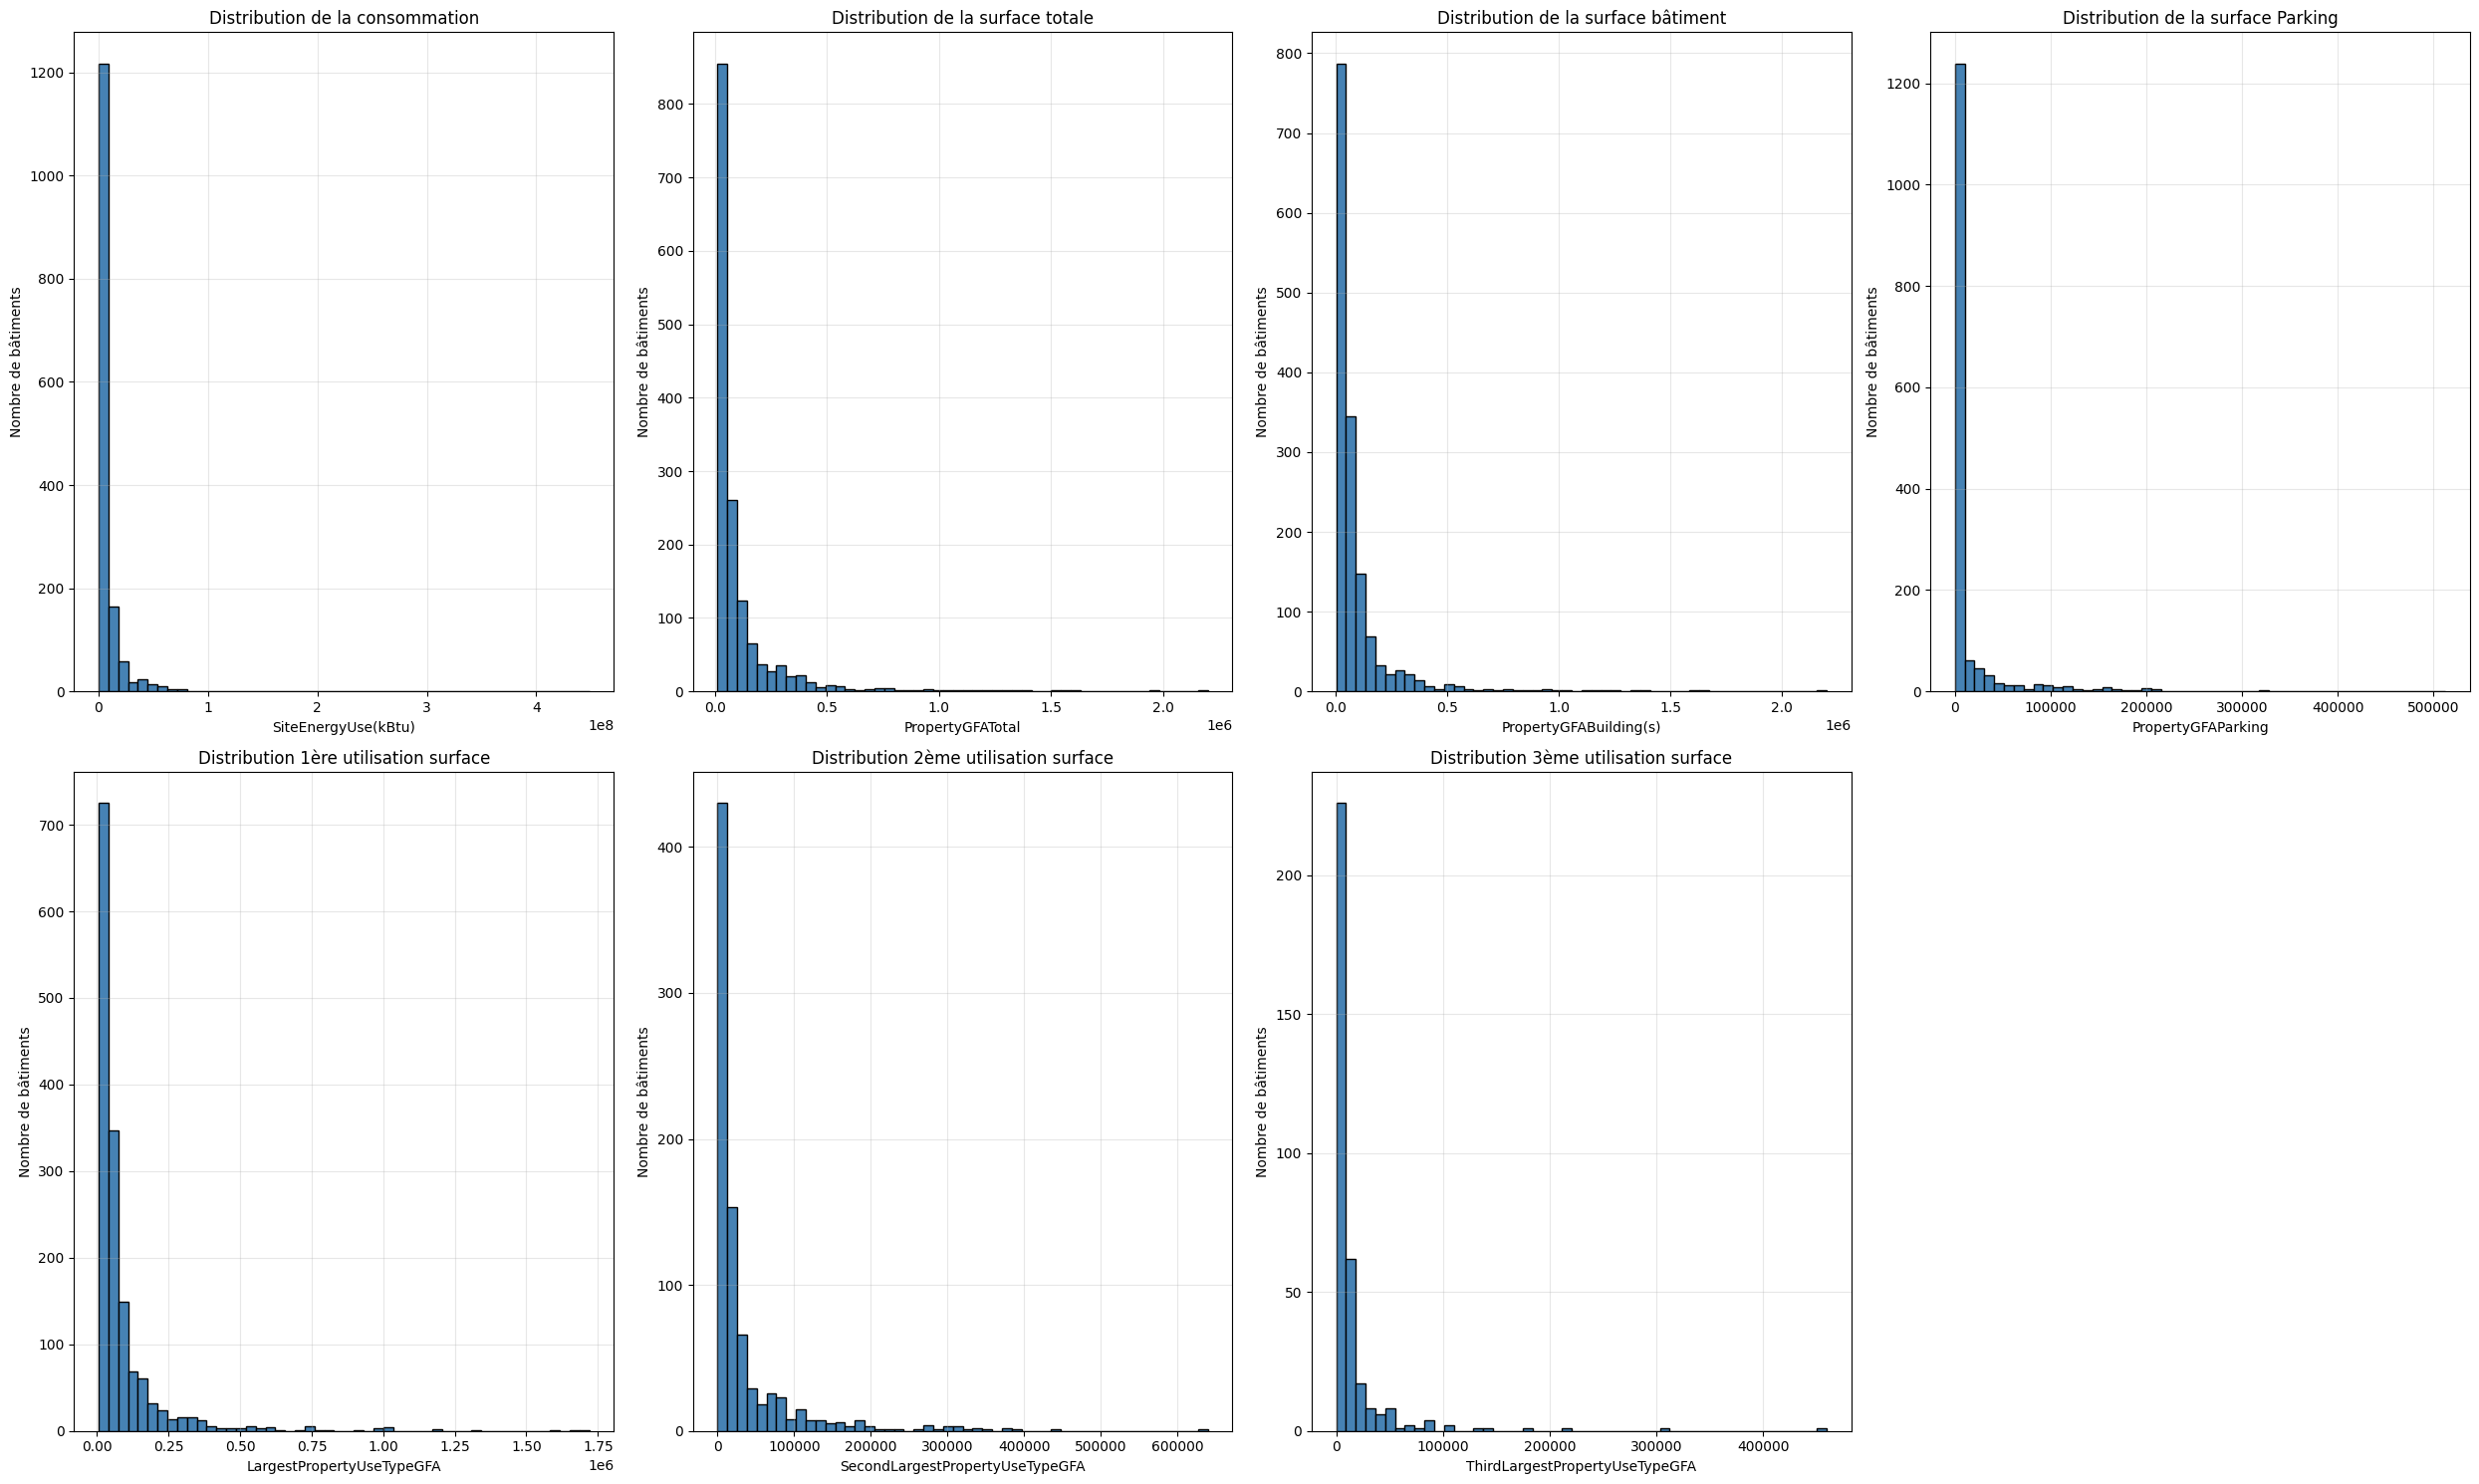

In [20]:
# Configuration des variables à visualiser
variables_config = {
    'SiteEnergyUse(kBtu)': 'Distribution de la consommation',
    'PropertyGFATotal': 'Distribution de la surface totale',
    'PropertyGFABuilding(s)': 'Distribution de la surface bâtiment',
    'PropertyGFAParking': 'Distribution de la surface Parking',
    'LargestPropertyUseTypeGFA': 'Distribution 1ère utilisation surface',
    'SecondLargestPropertyUseTypeGFA': 'Distribution 2ème utilisation surface',
    'ThirdLargestPropertyUseTypeGFA': 'Distribution 3ème utilisation surface'
}

# Création des graphiques
fig, axes = plt.subplots(2,4, figsize=(25, 15))
axes = axes.flatten() 

for idx, (col_name, title) in enumerate(variables_config.items()):
    axes[idx].hist(df[col_name], bins=50, color='steelblue', edgecolor='black')
    axes[idx].set_xlabel(col_name)
    axes[idx].set_ylabel('Nombre de bâtiments')
    axes[idx].set_title(title)
    axes[idx].grid(True, alpha=0.3)

axes[7].axis('off')

plt.tight_layout()
plt.show()

Nous observons que **l'ensemble des variables** (consommation énergétique et surfaces) présentent des distributions fortement asymétriques à droite :

**Caractéristiques communes :**
- **Concentration à gauche** : La majorité des bâtiments se situent dans les valeurs basses
- **Queue longue à droite** : Présence de quelques valeurs extrêmes (outliers)

```markdown
Conclusion

Il existe des outliers dans toutes les variables liées à la surface. 
```

---

#### 5.3 Analyse des distributions d'énergie VS type de bâtiments.

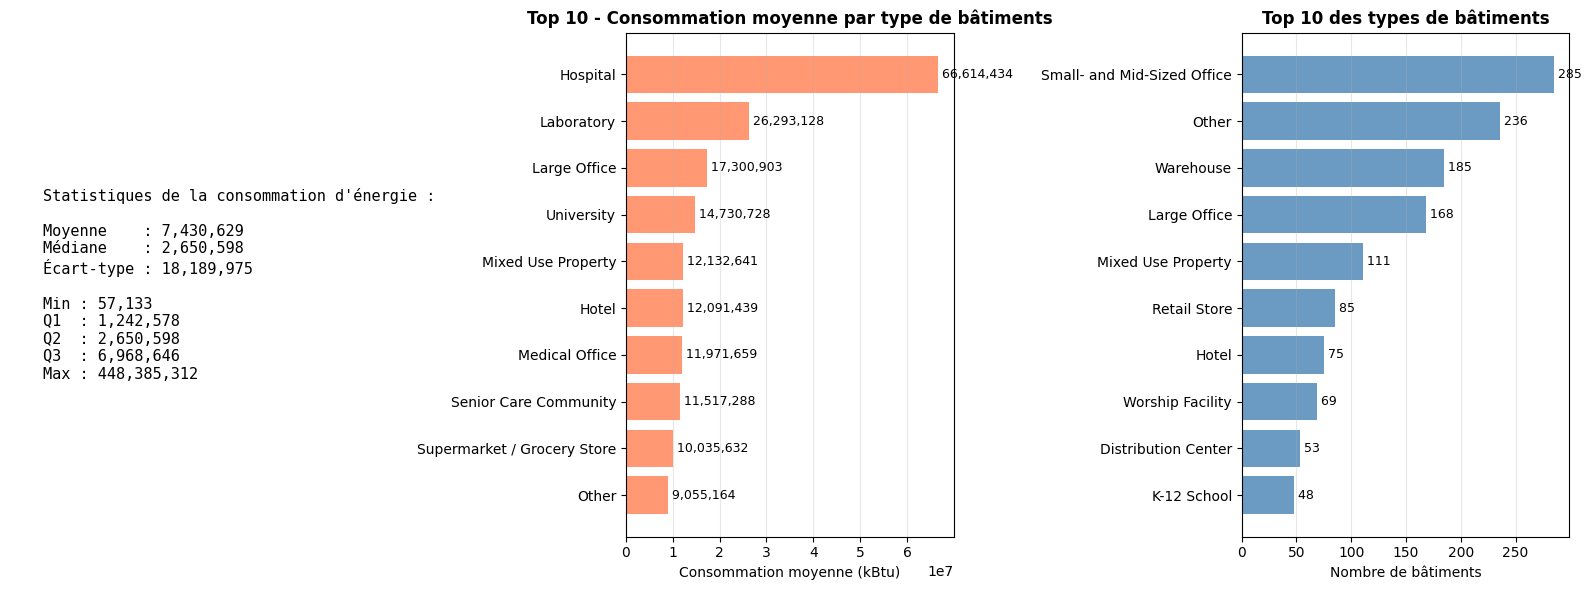

In [21]:
# Graphique 1 : Statistiques
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
stats_text = f"""
Statistiques de la consommation d'énergie :

Moyenne    : {df['SiteEnergyUse(kBtu)'].mean():,.0f}
Médiane    : {df['SiteEnergyUse(kBtu)'].median():,.0f}
Écart-type : {df['SiteEnergyUse(kBtu)'].std():,.0f}

Min : {df['SiteEnergyUse(kBtu)'].min():,.0f}
Q1  : {df['SiteEnergyUse(kBtu)'].quantile(0.25):,.0f}
Q2  : {df['SiteEnergyUse(kBtu)'].quantile(0.50):,.0f}
Q3  : {df['SiteEnergyUse(kBtu)'].quantile(0.75):,.0f}
Max : {df['SiteEnergyUse(kBtu)'].max():,.0f}
"""
axes[0].text(0.1, 0.5, stats_text, fontsize=11, family='monospace', verticalalignment='center')
axes[0].axis('off')

def create_top10_barh(ax, data, color, xlabel, title):
    ax.barh(range(len(data)), data.values, color=color, alpha=0.8)
    ax.set_yticks(range(len(data)))
    ax.set_yticklabels(data.index)
    ax.set_xlabel(xlabel)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.invert_yaxis()  # Pour avoir le plus grand en haut
    ax.grid(axis='x', alpha=0.3)
    
    # Ajouter les valeurs sur les barres
    for i, v in enumerate(data.values):
        ax.text(v, i, f' {v:,.0f}', va='center', fontsize=9)

# Graphique 1 : Consommation moyenne
mean_consumption = df.groupby('PrimaryPropertyType')['SiteEnergyUse(kBtu)'].mean().sort_values(ascending=False).head(10)
create_top10_barh(
    axes[1],  
    mean_consumption, 
    'coral', 
    'Consommation moyenne (kBtu)', 
    'Top 10 - Consommation moyenne par type de bâtiments'
)

# Graphique 2 : Nombre de bâtiments
type_counts = df['PrimaryPropertyType'].value_counts().head(10)
create_top10_barh(
    axes[2], 
    type_counts, 
    'steelblue', 
    'Nombre de bâtiments', 
    'Top 10 des types de bâtiments'
)

plt.tight_layout()
plt.show()

---

**Graphique Top 10 - Consommation moyenne par type de batiments**  
Les plus grands consommateurs d'énergie sont :
- concernant les `fortes consommations` (environ le double de la moyenne) :
    - **Hospital** (hôpitaux) : équipements médicaux fonctionnant 24h/24
    - **Laboratory** (laboratoires) : systèmes de ventilation et équipements spécialisés

- concernant les `consommations élevées` :
    - **Large Office** (grands bureaux) : climatisation, éclairage, serveurs
    - **University** (universités) : bâtiments multifonctions ouverts en continu
    - **Mixed Use Property** (propriétés mixtes) : combinaison d'usages résidentiels et commerciaux
    - **Hotel** (hôtels) : chauffage, eau chaude, climatisation 24h/24

**Graphique Top 10 des types de batiments.**  
Les types de bâtiments les plus fréquents dans le dataset sont :
    1. **Small and Mid-Sized Office** (petits et moyens bureaux)  
    2. **Other** (autres)  
    3. **Warehouse** (entrepôts)  
    
```markdown
Conclusion
```
La consommation énergétique dépend davantage du **type d'usage** du bâtiment que de sa **quantité de structures**.   
Un hôpital ou un laboratoire consomme significativement plus qu'un entrepôt, indépendamment du nombre de bâtiments de la propriété.

*Implication pour la modélisation :* Les variables qui concernant le type de bâtiment seront pertinentes pour prédire la consommation énergétique

---

---

## 6/ Partie 2 : Analyse des outliers de la variable cible : SiteEnergyUse(kBtu)
  - Methode de détection d'outliers : IQR et Z-score
  - Analyse des outliers de SiteEnergyUse(Kbtu)

#### 6.1. Évaluation de deux approches : IQR et Z-SCORE de la Target *SiteEnergyUse*

In [22]:
# ===== MÉTHODE 1 : IQR =====
print("\n1️⃣ MÉTHODE IQR (Interquartile Range)")
print("-"*80)

Q1 = df['SiteEnergyUse(kBtu)'].quantile(0.25)
Q3 = df['SiteEnergyUse(kBtu)'].quantile(0.75)
IQR = Q3 - Q1
limite_basse_iqr = Q1 - 1.5 * IQR
limite_haute_iqr = Q3 + 1.5 * IQR

outliers_iqr = df[(df['SiteEnergyUse(kBtu)'] < limite_basse_iqr) | 
                         (df['SiteEnergyUse(kBtu)'] > limite_haute_iqr)]

print(f"   Limite basse : {limite_basse_iqr:,.0f}")
print(f"   Limite haute : {limite_haute_iqr:,.0f}")
print(f"   IQR : {IQR:,.0f}")
print(f"   Nombre d'outliers détectés : {len(outliers_iqr)} ({len(outliers_iqr)/len(df)*100:.1f}%)")

# ===== MÉTHODE 2 : Z-SCORE =====
print("\n2️⃣ MÉTHODE Z-SCORE (écart à la moyenne)")
print("-"*80)

mean = df['SiteEnergyUse(kBtu)'].mean()
std = df['SiteEnergyUse(kBtu)'].std()

# Calculer le z-score pour chaque valeur
z_score = np.abs((df['SiteEnergyUse(kBtu)'] - mean) / std)

# Seuil classique : |z| > 3
outliers_zscore_mask = z_score > 3  
outliers_zscore = df[outliers_zscore_mask]  

print(f"   Moyenne : {mean:,.0f}")
print(f"   Écart-type : {std:,.0f}")
print(f"   Seuil utilisé : |z-score| > 3")
print(f"   Nombre d'outliers détectés : {len(outliers_zscore)} ({len(outliers_zscore)/len(df)*100:.1f}%)")

# ===== COMPARAISON =====
print("\n📊 COMPARAISON")
print("-"*80)
print(f"   IQR détecte : {len(outliers_iqr)} outliers")
print(f"   Z-score détecte : {len(outliers_zscore)} outliers")

# Combien sont communs aux deux méthodes ?
communs = set(outliers_iqr.index).intersection(set(outliers_zscore.index))
print(f"   Outliers communs aux deux méthodes : {len(communs)}")

print("\n" + "="*80)


1️⃣ MÉTHODE IQR (Interquartile Range)
--------------------------------------------------------------------------------
   Limite basse : -7,346,526
   Limite haute : 15,557,750
   IQR : 5,726,069
   Nombre d'outliers détectés : 169 (11.1%)

2️⃣ MÉTHODE Z-SCORE (écart à la moyenne)
--------------------------------------------------------------------------------
   Moyenne : 7,430,629
   Écart-type : 18,189,975
   Seuil utilisé : |z-score| > 3
   Nombre d'outliers détectés : 16 (1.1%)

📊 COMPARAISON
--------------------------------------------------------------------------------
   IQR détecte : 169 outliers
   Z-score détecte : 16 outliers
   Outliers communs aux deux méthodes : 16



In [23]:
print("="*80)
ecart_outlier=len(outliers_iqr)-len(outliers_zscore)
print(f"La méthode IQR trouve {ecart_outlier} outliers de + que le Z-score")
print(f"La dispersion des valeurs de IQR et Z-score est important : {std:,.0f} pour le Z-score et {IQR:,.0f} pour IQR")
print("="*80)

La méthode IQR trouve 153 outliers de + que le Z-score
La dispersion des valeurs de IQR et Z-score est important : 18,189,975 pour le Z-score et 5,726,069 pour IQR


 - **Z-score** est basé sur la moyenne des variables et prend en compte les Outliers ce qui biaise la *normalité* du score.     
 - **IQR** est basé sur le quartile, soit la dispersion entre Q1(25%) et Q3(75%).  
       IQR offre une vision plus réelle des données.   

*Pour une étude plus rigoureuse, je prends comme reference d'Outlier IQR.*

📊 VISUALISATION DE LA VARIABLE CIBLE : SiteEnergyUse(kBtu)
--------------------------------------------------------------------------------


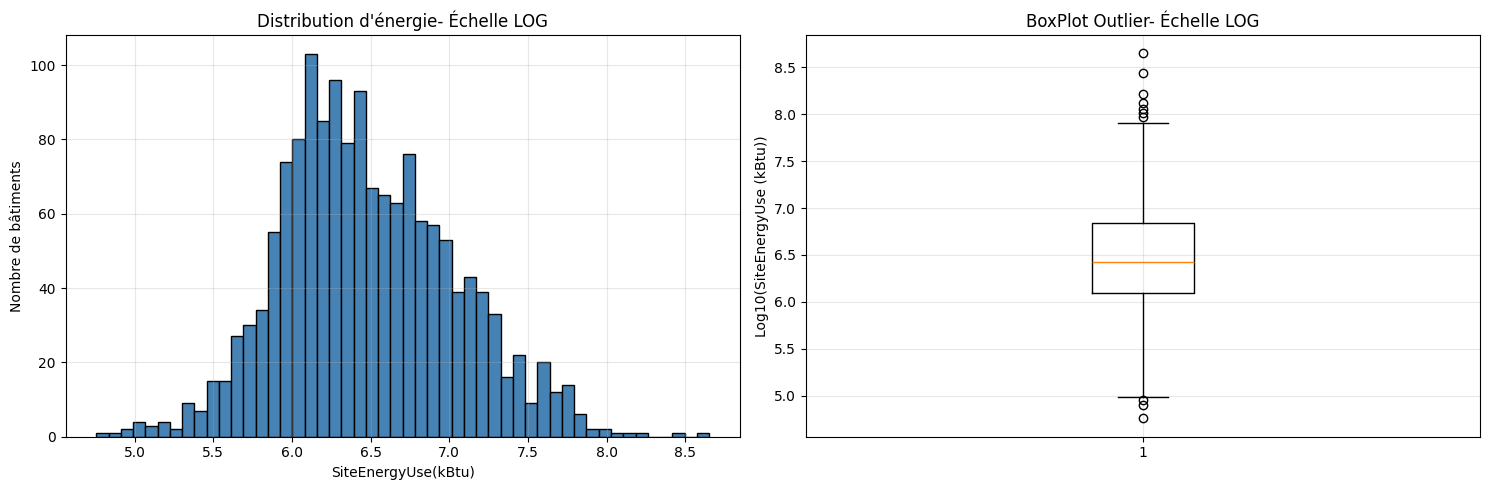

In [24]:
def fonction_visualisation(ax,data,graph_type,titre):
    if graph_type == 'histogram':
        ax.hist(np.log10(df['SiteEnergyUse(kBtu)'].dropna()+ 1), bins=50, color='steelblue', edgecolor='black')
        ax.set_xlabel('SiteEnergyUse(kBtu)')
        ax.set_ylabel('Nombre de bâtiments')

    elif graph_type == 'boxplot_log':
        ax.boxplot(np.log10(df['SiteEnergyUse(kBtu)'].dropna() + 1))
        ax.set_ylabel('Log10(SiteEnergyUse (kBtu))')

    ax.set_title(titre)
    ax.grid(True, alpha=0.3)
        
print("📊 VISUALISATION DE LA VARIABLE CIBLE : SiteEnergyUse(kBtu)")
print("-"*80)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

fonction_visualisation(axes[0],df['SiteEnergyUse(kBtu)'], 'histogram','Distribution d\'énergie- Échelle LOG')
fonction_visualisation(axes[1],df['SiteEnergyUse(kBtu)'], 'boxplot_log','BoxPlot Outlier- Échelle LOG')

plt.tight_layout()
plt.show()


```
L'histogramme de la distribution d'énergie montre des batiments isolés, soit des outlier vers l'échelle log 8.5.
Ce constat est validé par la visualitation du Boxplot, qui montre au delà du Q3 la présence d'outlier.
```

### 6.2. Anlayse des Outliers de la Target SiteEnergyUse

Dans la *Partie 5*, nous avons vu que la consommation d'énergie était liée au *type et la surfaces des individus*.   
On va effectuer une analyse des outliers de **SiteEnergyUse(kBtu)** en fonction des types de bâtiments via **PrimaryPropertyType** et en fonction de la surface des bâtiments via **PropertyGFATotal**.

In [25]:
Q1 = df['SiteEnergyUse(kBtu)'].quantile(0.25)
Q3 = df['SiteEnergyUse(kBtu)'].quantile(0.75)
IQR = Q3 - Q1
limite_basse = Q1 - 1.5 * IQR
limite_haute = Q3 + 1.5 * IQR
outliers = df[df['SiteEnergyUse(kBtu)'] > limite_haute]
types_outliers = outliers['PrimaryPropertyType'].value_counts()
types_outliersGFA = outliers['PropertyGFATotal'].value_counts()

#type
print("\n" + "="*60)
print("📊 ANALYSE DES OUTLIERS - TYPES DE BÂTIMENTS")
print("="*60)

df_type = pd.DataFrame({
    'Nombre': types_outliers,
    'Pourcentage (%)': (types_outliers / len(outliers) * 100).round(1)
})

display(df_type)

#surface
print("\n" + "="*60)
print(f"📊 ANALYSE DES OUTLIERS - SURFACES DES BÂTIMENTS:")
print("="*60)   
print(outliers['PropertyGFATotal'].describe().round(1))

#top 5 + gros consommateur
print("\n" + "="*60)
print(f"📊 Top 5 des plus gros consommateurs parmi les outliers:")
print("="*60)
top5 = outliers.nlargest(5, 'SiteEnergyUse(kBtu)')[['PrimaryPropertyType','PropertyGFATotal','SiteEnergyUse(kBtu)']]
display(top5)


📊 ANALYSE DES OUTLIERS - TYPES DE BÂTIMENTS


,Nombre,Pourcentage (%)
PrimaryPropertyType,,
Large Office,66,39.1
Other,29,17.2
Mixed Use Property,16,9.5
Hotel,15,8.9
Medical Office,12,7.1
Retail Store,6,3.6
Laboratory,6,3.6
Senior Care Community,5,3.0
University,4,2.4



📊 ANALYSE DES OUTLIERS - SURFACES DES BÂTIMENTS:
count        169.0
mean      456632.1
std       388629.3
min        33971.0
25%       190000.0
50%       336330.0
75%       540360.0
max      2200000.0
Name: PropertyGFATotal, dtype: float64

📊 Top 5 des plus gros consommateurs parmi les outliers:


,PrimaryPropertyType,PropertyGFATotal,SiteEnergyUse(kBtu)
35,Mixed Use Property,494835,448385312.0
558,Other,429405,274682208.0
3264,Hospital,374466,163945984.0
340,Other,535947,131373880.0
1494,University,2200000,114648520.0


**Analyse**  
Le tableau "Analyse des outliers-Type de batiments" montre la répartition des gros consommateurs d'énergie en nombre :  
  - les **Large Office** (grands bureau) sont les plus nombreux et representent 39% des types gros consommateurs
  - les **other** (autres) représentent  17% des gros consommateurs
  - Les **Mixed Use Property** (propriété mixed) représentent 9% des gros consommateurs.  


L'analyse croisée avec la surface nous montre que : 
  - la plus grosse superficie (University : 2 200 000) est le seul outlier de surface (5e position). Les 4 autres ont une superficie qui oscile entre la **médiane** et **Q3**, ce qui signifie qu'ils consomment énormément d'énergie malgré une surface "normale".

  ```
  Conclusion
  La superficie n'est pas un élément prépondérant dans la consommation, mais il reste important.
  ```

#### a. Analyse des individus "Other" dans Outlier de la target

In [26]:
Q1 = df['SiteEnergyUse(kBtu)'].quantile(0.25)
Q3 = df['SiteEnergyUse(kBtu)'].quantile(0.75)
IQR = Q3 - Q1
limite_haute = Q3 + 1.5 * IQR

outliers = df[df['SiteEnergyUse(kBtu)'] > limite_haute]

# Filtrer les "Other" dans 'PrimaryPropertyType'/ il y en a 29
other_outliers = outliers[outliers['PrimaryPropertyType'] == 'Other']

# Usage principal réel
print("\n 1/ Usage principal (LargestPropertyUseType) :")
print(other_outliers['LargestPropertyUseType'].value_counts())

# Top 5 les + energivores
print("--------"*10)
print("\n 3/ Top 10 les plus énergivores :")
display(other_outliers.nlargest(10, 'SiteEnergyUse(kBtu)')[
    ['BuildingType','LargestPropertyUseType', 'PropertyGFABuilding(s)', 'SiteEnergyUse(kBtu)','NumberofBuildings' ]
])


 1/ Usage principal (LargestPropertyUseType) :
LargestPropertyUseType
Other                                    13
Other - Entertainment/Public Assembly     3
Data Center                               3
Urgent Care/Clinic/Other Outpatient       2
Other - Recreation                        2
Library                                   1
Courthouse                                1
Parking                                   1
Strip Mall                                1
Other - Mall                              1
Lifestyle Center                          1
Name: count, dtype: int64
--------------------------------------------------------------------------------

 3/ Top 10 les plus énergivores :


,BuildingType,LargestPropertyUseType,PropertyGFABuilding(s),SiteEnergyUse(kBtu),NumberofBuildings
558,NonResidential,Data Center,429405,274682208.0,1.0
340,Campus,Other,535947,131373880.0,1.0
119,NonResidential,Other,230638,65336980.0,1.0
187,NonResidential,Other,230880,62197176.0,1.0
329,NonResidential,Urgent Care/Clinic/Other Outpatient,158738,61762380.0,1.0
155,NonResidential,Other - Entertainment/Public Assembly,1258280,59757440.0,1.0
158,NonResidential,Other - Entertainment/Public Assembly,1172127,58761304.0,1.0
21,NonResidential,Other,385274,47859812.0,1.0
564,NonResidential,Other - Mall,947987,46510960.0,1.0
20,NonResidential,Courthouse,540360,44984468.0,1.0


---

**On remarque 2 individus avec une consommation d'énergie importante : l'individu avec ID 558, un Data Center, et le 340, un parking Campus**  
**Analysons leurs données en surface et consommation**

---

In [27]:
DC_GFA = df.loc[558, 'PropertyGFABuilding(s)']
CP_GFA = df.loc[340, 'PropertyGFABuilding(s)']
DC_use = df.loc[558, 'SiteEnergyUse(kBtu)']
CP_use = df.loc[340, 'SiteEnergyUse(kBtu)']
Q3_target = df['SiteEnergyUse(kBtu)'].quantile(0.75).round(1)
max_PropertyGFABuilding = df['PropertyGFABuilding(s)'].max()

print(f"Le Data Center a une surface de {DC_GFA}, bien inferieur au plus gros batiments (max:{max_PropertyGFABuilding})")
print(f"et petit que le 2nd plus gros consommateur (le parking Campus {CP_GFA}).")
print(f"Pourtant sa consommation d'énergie ({DC_use}) est un des plus important outlier,en comparaison avec le dernier quartile de la target Q3 = {Q3_target}")
print("--------"*10)
print(f"Le Campus Parking a une surface de {CP_GFA}, bien inferieur au plus gros batiments (max:{max_PropertyGFABuilding})")
print(f"et pourtant sa consommation d'énergie ({CP_use}) est le 2nd plus important outlier,en comparaison avec le dernier quartile de la target Q3 = {Q3_target}")

Le Data Center a une surface de 429405, bien inferieur au plus gros batiments (max:2200000)
et petit que le 2nd plus gros consommateur (le parking Campus 535947).
Pourtant sa consommation d'énergie (274682208.0) est un des plus important outlier,en comparaison avec le dernier quartile de la target Q3 = 6968646.4
--------------------------------------------------------------------------------
Le Campus Parking a une surface de 535947, bien inferieur au plus gros batiments (max:2200000)
et pourtant sa consommation d'énergie (131373880.0) est le 2nd plus important outlier,en comparaison avec le dernier quartile de la target Q3 = 6968646.4


---

## 7 / Visualisation des features incomplètes

/tmp/ipykernel_1036072/1784392954.py:30: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/veron/miniconda3/envs/seattle/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


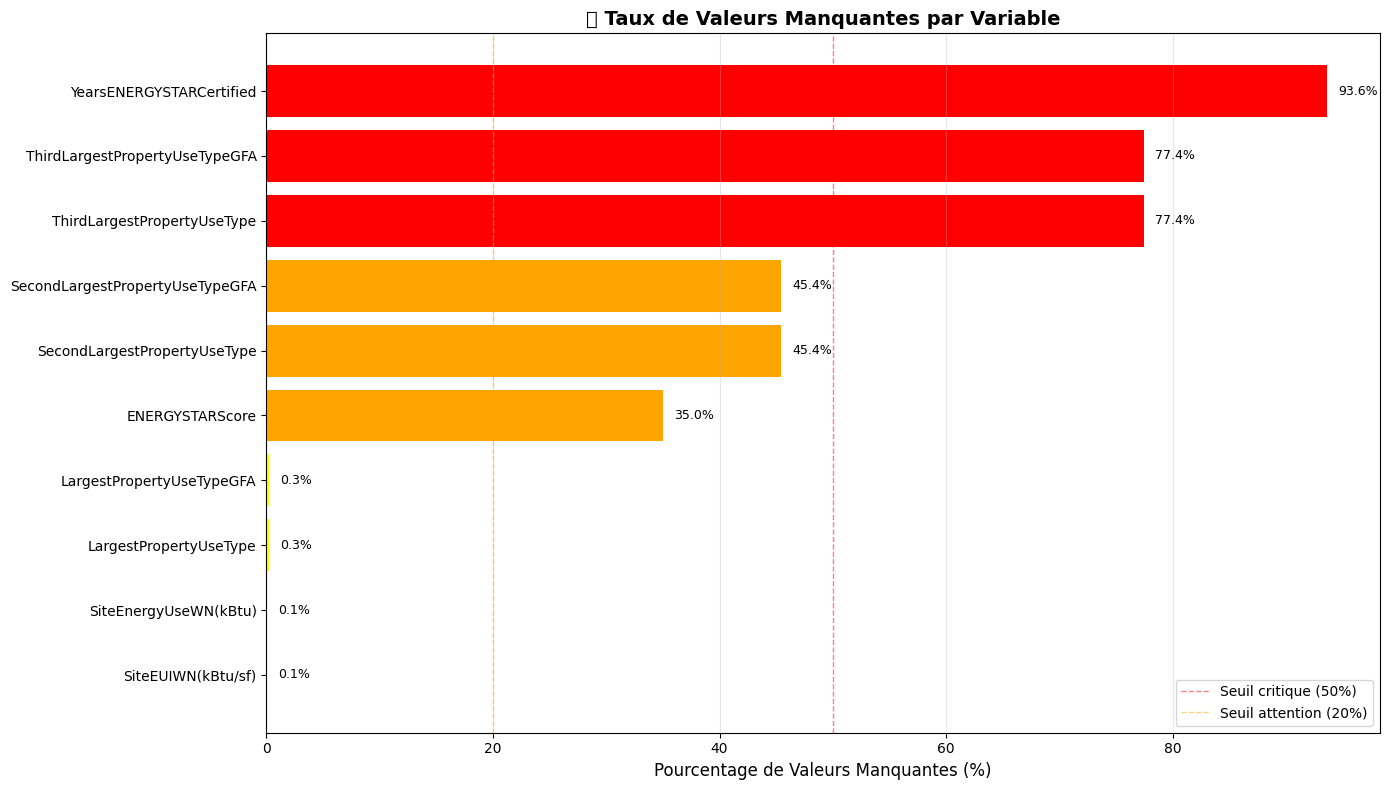

In [28]:
missing = pd.DataFrame({
    'Colonne': df.columns,
    'NaN_Count': df.isnull().sum(),
    'NaN_Percent': (df.isnull().sum() / len(df) * 100).round(2),
    'Type': df.dtypes
})

missing = missing[missing['NaN_Count'] > 0].sort_values('NaN_Percent', ascending=False)
fig, ax = plt.subplots(figsize=(14, 8))

if len(missing) > 0:
    missing_sorted = missing.sort_values('NaN_Percent', ascending=True)
    colors = ['red' if x > 50 else 'orange' if x > 20 else 'yellow' 
              for x in missing_sorted['NaN_Percent']]
    
    bars = ax.barh(missing_sorted['Colonne'], missing_sorted['NaN_Percent'], color=colors)
    ax.set_xlabel('Pourcentage de Valeurs Manquantes (%)', fontsize=12)
    ax.set_title('📊 Taux de Valeurs Manquantes par Variable', fontsize=14, fontweight='bold')
    ax.axvline(x=50, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Seuil critique (50%)')
    ax.axvline(x=20, color='orange', linestyle='--', linewidth=1, alpha=0.5, label='Seuil attention (20%)')
    ax.legend()
    ax.grid(axis='x', alpha=0.3)
    
    # Ajouter les valeurs sur les barres
    for i, bar in enumerate(bars):
        width = bar.get_width()
        ax.text(width + 1, bar.get_y() + bar.get_height()/2, 
                f'{width:.1f}%', ha='left', va='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()
else:
    print("✅ Aucune valeur manquante dans le dataset !")

---

**La variable YearsENERGYSTARCertified n'est pas pertinente car les données sont vides. Je supprime cette variable**

---

### 7.1 Suppression de YearsENERGYSTARCertified

In [29]:
df = df.drop(columns=['YearsENERGYSTARCertified'])

### 7.2 Enregistrement du nouveau Dataset

In [30]:
df.to_pickle('df_clean.pkl')
print("✅ Fichier sauvegardé en pickle")
print("\n" + "="*60)
print("📊 RÉCAPITULATIF :")
print(f"  Dataset initial : {len(df_initial ):,} lignes × {len(df_initial .columns)} colonnes")
print(f"  Dataset final : {len(df):,} lignes × {len(df.columns)} colonnes")
print("="*60+"\n")
print("📊 Le nouveau Dataset :")
df.info()

✅ Fichier sauvegardé en pickle

📊 RÉCAPITULATIF :
  Dataset initial : 3,376 lignes × 46 colonnes
  Dataset final : 1,520 lignes × 32 colonnes

📊 Le nouveau Dataset :
<class 'pandas.core.frame.DataFrame'>
Index: 1520 entries, 0 to 3375
Data columns (total 32 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   DataYear                         1520 non-null   int64  
 1   BuildingType                     1520 non-null   object 
 2   PrimaryPropertyType              1520 non-null   object 
 3   CouncilDistrictCode              1520 non-null   int64  
 4   Neighborhood                     1520 non-null   object 
 5   Latitude                         1520 non-null   float64
 6   Longitude                        1520 non-null   float64
 7   YearBuilt                        1520 non-null   int64  
 8   NumberofBuildings                1520 non-null   float64
 9   NumberofFloors                   1520 non-nul

---

## Conclusion de l'Analyse Exploratoire

L'analyse exploratoire a permis d'identifier les caractéristiques principales 
du jeu de données sur la consommation énergétique des bâtiments de Seattle :

**Principales découvertes :**
- Un Dataset réduit de moitié suite au nettoyage de données
- Choix de la variable cible (Targetà SiteEnergyUse(Kbtu)
- Présence d'outliers détectés par méthode IQR et Z-score
- Variables clés identifiées : type de batiments, surface du batiment.

**Prochaine étape :**
La phase de modélisation permettra de construire un modèle prédictif 
de la consommation énergétique pour aider la ville de Seattle dans 
sa stratégie de neutralité carbone 2050.

---